<a href="https://www.kaggle.com/code/maryamismail95/spam-detection-through-csv-file?scriptVersionId=322967868" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Spam Detection Through CSV file 
In this code or reposotory i will be creating a system called spam detection system through csv file.

# Import and Run Necessary Libraries
 1 - pandas for data loading and preprocessing and cleaning
 2 - through sklearn.model_selection we will import train test split for splitting data into test and train where test will be 20% of data through which rest of 80% data will be trained
 3 - throuh sklearn.feature_extraction.text module we will import TfidVectorizer, it converts raw text into numerical numbers, which is necessary for machine to understanding.
 4 - through sklearn.naive_bayes we will import MultinomialNB for classification either it is spam or ham
 5 - through sklearn.metrics we import accuracy score and Classification report for the accuracy of our model.


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score , classification_report



# load Csv file/ Data


In [5]:
df = pd.read_csv('/kaggle/input/datasets/shantanudhakadd/email-spam-detection-dataset-classification/spam.csv' , encoding= 'latin-1')

In [6]:
df.head

<bound method NDFrame.head of         v1                                                 v2 Unnamed: 2  \
0      ham  Go until jurong point, crazy.. Available only ...        NaN   
1      ham                      Ok lar... Joking wif u oni...        NaN   
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3      ham  U dun say so early hor... U c already then say...        NaN   
4      ham  Nah I don't think he goes to usf, he lives aro...        NaN   
...    ...                                                ...        ...   
5567  spam  This is the 2nd time we have tried 2 contact u...        NaN   
5568   ham              Will Ì_ b going to esplanade fr home?        NaN   
5569   ham  Pity, * was in mood for that. So...any other s...        NaN   
5570   ham  The guy did some bitching but I acted like i'd...        NaN   
5571   ham                         Rofl. Its true to its name        NaN   

     Unnamed: 3 Unnamed: 4  
0           NaN        NaN  

# Data Preprocessing and Splitting
Data spliting is essential part of Machine Learning, Data is split into 2 parts, 20% for test and rest of 80% is  for training the model,Spliting, renaming, Data Cleaning , handling missing values are the part of data preprocessing.
If we go through from our dataset, we ave been given  with 2 columns name V1 and V2, first we will split it into 2 parts for test and train and rename it.

In [7]:
df =df.rename(columns={'v1':'label' ,'v2':'text'})
df.columns

Index(['label', 'text', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [8]:
X =df['text']
y =df['label']

# Dividing Data  into Test and Train

In [9]:
X_train,X_test,y_train,y_test =train_test_split(X,y ,test_size = 0.2 , random_state =42)

# Cleaning the unwanted Columns

In [10]:
df= df.iloc[: , : 2]
df.columns = ['label' ,'text']
df.head(10)

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


# Vectorization
In Vectorizaton, it changes text into numbers for machine understanding

In [11]:
# initilizing VEctorizer

vectorizer = TfidfVectorizer(stop_words='english')

# Vectorization of training Data
X_train_tfidf = vectorizer.fit_transform(X_train)

# Vectorization of Testing Data
X_test_tfidf = vectorizer.transform(X_test)

print("Vectorization is successfully completed")

Vectorization is successfully completed


# Model Training

In [12]:
# Making Naive Bayes Model
model = MultinomialNB()

# training Model through Data
model.fit(X_train_tfidf, y_train)
# model has been fitted and trained
print("Model is trained")

Model is trained


# Prediction

In [13]:
# prediction on test data
prediction = model.predict(X_test_tfidf)

# Accuracy Score on y test prediction
accuracy = int(accuracy_score(y_test,prediction) * 100)

# classification report on y test and prediction
class_report = classification_report(y_test,prediction)
# Accuracy Printing
print(" The Accuracy Score is: ",  accuracy ,"%")
print(" The Classification Report is :" , class_report)

 The Accuracy Score is:  96 %
 The Classification Report is :               precision    recall  f1-score   support

         ham       0.96      1.00      0.98       965
        spam       1.00      0.75      0.86       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



# Live testing

In [14]:
message = input(" Enter your Messgage for detection")
message_tfidf = vectorizer.transform([message])

output = model.predict(message_tfidf)
print(f"The message your enter was :{output[0]}")

 Enter your Messgage for detection how are you


The message your enter was :ham


# Data Visualization
For Data Visualization, we will generate graphs for better understanding of outcome
for Spam Detection, we do 3 type of graphs,
Confusion matrix , Distribution of Message length , Distribution of Spam Vs Ham messages

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Graph 1
# Distribution of Ham vs Spam Messages

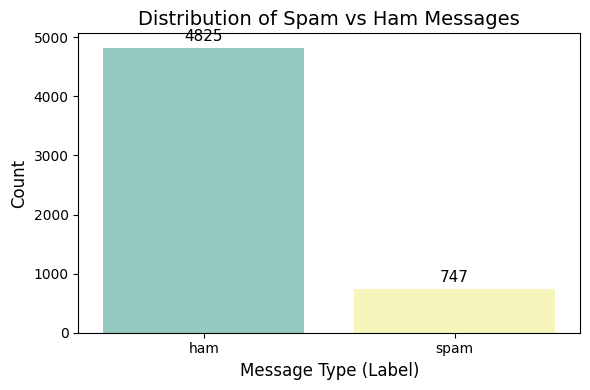

In [16]:
#  Declaring Size of Graph
plt.figure(figsize =(6,4))

# Bar Chart on the base of label columns
ax = sns.countplot(x = 'label' , data = df , palette = 'Set3' ,hue='label',legend=False, order =df['label'].value_counts().index)

# puting Titles and labells
plt.title('Distribution of Spam vs Ham Messages', fontsize=14)
plt.xlabel('Message Type (Label)', fontsize=12)
plt.ylabel('Count', fontsize=12)

# for bar Chart , giving numbers  to bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.tight_layout()
plt.show()

# Graph 2
# Distribution of Message Lengths (Spam vs Ham)

Text(0, 0.5, 'Density')

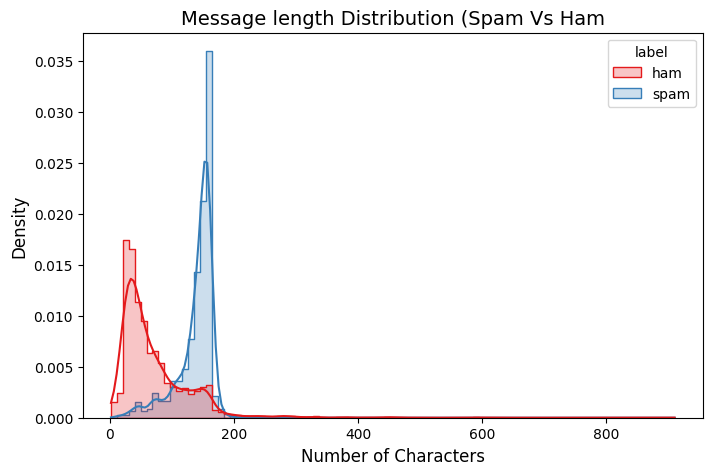

In [17]:
#  column making of each character in message
df["length"] =df["text"].apply(len)

# setting graph size
plt.figure(figsize = (8 , 5))

# histogram (Density Plot)

sns.histplot(data = df , x = 'length' , hue = 'label' ,element = 'step' ,stat='density' ,common_norm = False, palette = 'Set1', kde =True )


# Title and label of graph
plt.title('Message length Distribution (Spam Vs Ham' , fontsize=14)
plt.xlabel('Number of Characters' , fontsize=12)
plt.ylabel('Density' , fontsize=12)

# Graph 3
# Confusion Matrix (The Model Performance Graph)

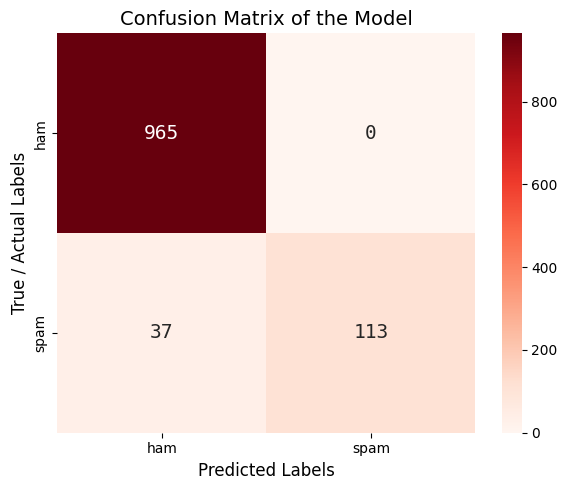

In [22]:
#  Confusion Matrix Calculation
c_matrix = confusion_matrix(y_test, prediction, labels = model.classes_)

# Setting Graph Size and its visualizing element 

plt.figure(figsize=(6,5))
sns.heatmap(c_matrix , annot = True , fmt='d' , cmap= 'Reds' ,xticklabels = model.classes_ ,yticklabels = model.classes_ , cbar = True , annot_kws ={"size" :14 , "fontfamily": "monospace"} )

# titles and labels
plt.title('Confusion Matrix of the Model' , fontsize = 14)
plt.xlabel('Predicted Labels', fontsize = 12)
plt.ylabel('True / Actual Labels' , fontsize = 12)

# graph adjustment
plt.tight_layout()

# final output 
plt.show()


# Additonal writings
If any thing which is wrong or needs to be edit, feel free to do it and let me know about it.

See Ya!